# Lab 10: Neural Networks — Graded Tasks
TensorFlow / Keras implementations for Tasks 1–9.

In [ ]:
# Shared imports for all tasks
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

### Task 1: Predict university admission from GPA & GRE

In [ ]:
# Features: [GPA (0-4), GRE (260-340)]; Label: 1 = admitted, 0 = rejected
X = np.array([[3.9,335],[3.7,325],[3.5,315],[3.2,310],[3.8,330],
              [2.8,295],[2.5,285],[3.0,300],[3.6,320],[2.7,290]], dtype=np.float32)
y = np.array([1,1,1,1,1,0,0,0,1,0], dtype=np.float32)

# Normalize data column/feature wise
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')    # sigmoid -> probability of admission
])
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_norm, y, epochs=200, verbose=0)

loss, acc = model.evaluate(X_norm, y, verbose=0)
print(f"Loss: {loss:.4f}, Accuracy: {acc:.4f}")
print("Admission probability for GPA=3.6, GRE=320:",
      model.predict(((np.array([[3.6,320]]) - X.mean(axis=0)) / X.std(axis=0)), verbose=0)[0][0])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Loss: 0.3868, Accuracy: 1.0000
Admission probability for GPA=3.6, GRE=320: 0.6638964


### Task 2: MNIST digit classification with SGD

In [3]:
# MNIST: 28x28 grayscale images, 10 classes (digits 0-9)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale pixels to [0,1] and flatten to 784-d vectors for a dense network
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 784).astype('float32') / 255.0

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')   # softmax -> class probabilities
])
# sparse_categorical_crossentropy: labels are ints, not one-hot
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_split=0.1, verbose=1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8067 - loss: 0.7143 - val_accuracy: 0.9218 - val_loss: 0.2831
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9116 - loss: 0.3089 - val_accuracy: 0.9353 - val_loss: 0.2244
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9265 - loss: 0.2545 - val_accuracy: 0.9447 - val_loss: 0.1930
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9374 - loss: 0.2196 - val_accuracy: 0.9527 - val_loss: 0.1703
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9442 - loss: 0.1940 - val_accuracy: 0.9580 - val_loss: 0.1535
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9501 - loss: 0.1739 - val_accuracy: 0.9613 - val_loss: 0.1412
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1575 - val_accuracy: 0.9647 - val_loss: 0.1312
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━

### Task 3: House price category (low/high) from area & rooms

In [4]:
# Synthesize 200 samples: area (sq ft) and rooms; label = high-price if price > median
N = 200
area  = np.random.uniform(500, 4000, N)
rooms = np.random.randint(1, 7, N)
price = 80*area + 15000*rooms + np.random.normal(0, 20000, N)   # latent price model
y = (price > np.median(price)).astype(np.float32)               # 1=high, 0=low

X = np.stack([area, rooms], axis=1).astype('float32')
X = (X - X.mean(axis=0)) / X.std(axis=0)   # standardize features

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(8,  activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=100, batch_size=16, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print(f"Loss: {loss:.4f}, Accuracy: {acc:.4f}")

Loss: 0.1825, Accuracy: 0.9150


### Task 4: Evaluate accuracy across different activation functions

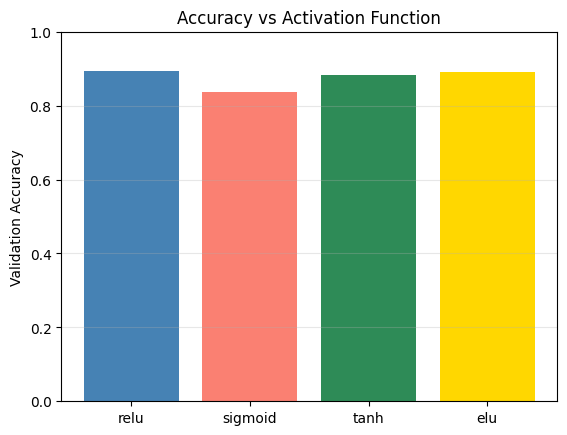

{'relu': 0.8930000066757202, 'sigmoid': 0.8374999761581421, 'tanh': 0.8824999928474426, 'elu': 0.8899999856948853}


In [5]:
# Reuse MNIST data (flattened). Train identical architecture with different hidden activations.
activations = ['relu', 'sigmoid', 'tanh', 'elu']
final_accs = {}

# Use a 10k subset for speed; same train/val split across runs
xs, ys = x_train[:10000], y_train[:10000]

for act in activations:
    m = keras.Sequential([
        layers.Dense(64, activation=act, input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(xs, ys, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    final_accs[act] = h.history['val_accuracy'][-1]

plt.bar(final_accs.keys(), final_accs.values(), color=['steelblue','salmon','seagreen','gold'])
plt.ylabel('Validation Accuracy'); plt.title('Accuracy vs Activation Function')
plt.ylim(0, 1); plt.grid(axis='y', alpha=0.3); plt.show()
print(final_accs)